<a href="https://colab.research.google.com/github/Mano-designz/bo101/blob/main/noisescaling_analysis_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV/V2G QAOA — Measured Noise Scaling Analysis

This notebook is a clean, reproducible quantum-computing experiment for the EV/V2G scheduling project.

### What this notebook does
1. Defines a small EV/V2G binary optimization problem as a QUBO.
2. Solves the same problem exactly with a classical brute-force baseline.
3. Builds a real QAOA circuit in Qiskit.
4. Displays the circuit graphically with `qc.draw("mpl")`.
5. Optimizes QAOA parameters using an ideal statevector simulation.
6. Runs the optimized circuit with Qiskit Aer.
7. Applies an explicit depolarizing noise model and **measures** the effect of noise.
8. Sweeps several noise strengths and plots the measured probability of the optimal EV schedule.
9. Repeats the experiment for several QAOA depths.
10. Performs a measured Zero-Noise Extrapolation (ZNE) experiment.

**Important:** Results in this notebook are generated by Qiskit/Qiskit Aer at runtime. No fake solution-quality values or claimed IBM-hardware results are inserted.


In [1]:
# Install the packages required by this notebook.
# Run this cell first in Google Colab.

!pip install -q qiskit qiskit-aer matplotlib scipy pylatexenc

print("Packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.9 MB/s eta 0:00:00
Packages installed.


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

print("Qiskit environment loaded successfully.")


Qiskit environment loaded successfully.


## 1. EV/V2G optimization problem

We use two binary scheduling decisions:

- `x0 = 1`: use the peak-period EV/V2G action.
- `x1 = 1`: use the off-peak-period EV/V2G action.

For this demonstration, the objective is

\[
C(x_0,x_1)=5x_0+x_1+4x_0x_1.
\]

The quadratic term penalizes selecting both blocks simultaneously.

This is intentionally a **small demonstration QUBO** so that the quantum circuit can be visualized and the complete noise experiment can be run quickly. It is not being presented as the full fleet-scale EV model.


In [3]:
# Define the QUBO objective.

def cost_function(x0, x1):
    return 5*x0 + 1*x1 + 4*x0*x1

all_solutions = []
for x0 in [0, 1]:
    for x1 in [0, 1]:
        all_solutions.append({
            "x0": x0,
            "x1": x1,
            "objective": cost_function(x0, x1)
        })

classical_df = pd.DataFrame(all_solutions)
classical_df


,x0,x1,objective
0,0,0,0
1,0,1,1
2,1,0,5
3,1,1,10


In [4]:
# Classical exact baseline

classical_best = min(all_solutions, key=lambda row: row["objective"])
optimal_bits = (classical_best["x0"], classical_best["x1"])
optimal_cost = classical_best["objective"]

print("Classical optimal schedule:", optimal_bits)
print("Classical optimal objective:", optimal_cost)


Classical optimal schedule: (0, 0)
Classical optimal objective: 0


## 2. QAOA circuit construction

For the QUBO

\[
5x_0+x_1+4x_0x_1,
\]

we convert the binary variables using

\[
x_i=(1-Z_i)/2.
\]

Ignoring the global constant, the cost Hamiltonian contains:

\[
-2.5Z_0-0.5Z_1+Z_0Z_1.
\]

The QAOA cost layer therefore uses `RZ` and `RZZ` rotations, followed by the standard `RX` mixer layer.

The circuit below is a genuine Qiskit QAOA-style circuit; it is not a hand-drawn image.


In [5]:
def create_qaoa_circuit(gamma, beta, p=1, measure=False):
    qc = QuantumCircuit(2, 2) if measure else QuantumCircuit(2)

    # Initial |++> state
    qc.h(0)
    qc.h(1)

    for _ in range(p):
        # Cost Hamiltonian for the EV/V2G QUBO
        qc.rz(5 * gamma, 0)
        qc.rz(1 * gamma, 1)
        qc.rzz(2 * gamma, 0, 1)

        # Standard QAOA mixer
        qc.rx(2 * beta, 0)
        qc.rx(2 * beta, 1)

    if measure:
        qc.measure(0, 0)
        qc.measure(1, 1)

    return qc

# Example p=1 circuit
example_gamma = 0.5
example_beta = 0.3

qc = create_qaoa_circuit(
    gamma=example_gamma,
    beta=example_beta,
    p=1,
    measure=True
)

print(qc)


     ┌───┐┌─────────┐        ┌─────────┐┌─┐   
q_0: ┤ H ├┤ Rz(2.5) ├─■──────┤ Rx(0.6) ├┤M├───
     ├───┤├─────────┤ │ZZ(1) ├─────────┤└╥┘┌─┐
q_1: ┤ H ├┤ Rz(0.5) ├─■──────┤ Rx(0.6) ├─╫─┤M├
     └───┘└─────────┘        └─────────┘ ║ └╥┘
c: 2/════════════════════════════════════╩══╩═
                                         0  1 


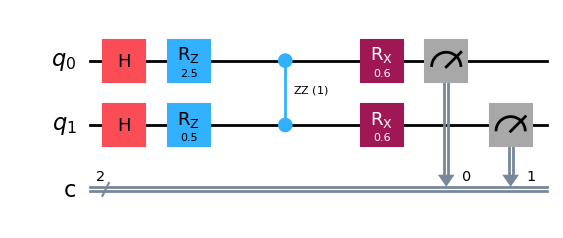

In [6]:
# Graphical circuit.
# pylatexenc was installed in the first cell so this should render graphically.

qc.draw("mpl")


## 3. Optimize the QAOA parameters

The parameters `gamma` and `beta` should not be chosen arbitrarily for the final experiment.

We use an ideal statevector simulation to minimize the expected QUBO cost. This is the **parameter-training stage**. After the parameters are obtained, we use Qiskit Aer to perform finite-shot measurements and the noisy experiment.


In [7]:
def expected_cost_from_statevector(statevector):
    probabilities = statevector.probabilities()

    expectation = 0.0

    # Qiskit uses little-endian basis ordering:
    # index bit 0 corresponds to q0 and bit 1 to q1.
    for index, probability in enumerate(probabilities):
        x0 = (index >> 0) & 1
        x1 = (index >> 1) & 1
        expectation += probability * cost_function(x0, x1)

    return float(expectation)


def qaoa_expectation(params, p=1):
    gamma, beta = params

    circuit = create_qaoa_circuit(
        gamma=gamma,
        beta=beta,
        p=p,
        measure=False
    )

    state = Statevector.from_instruction(circuit)
    return expected_cost_from_statevector(state)


# Optimize p=1 parameters.
initial_parameters = np.array([0.5, 0.3])

optimization_result = minimize(
    qaoa_expectation,
    initial_parameters,
    args=(1,),
    method="COBYLA",
    options={"maxiter": 100}
)

best_gamma = float(optimization_result.x[0])
best_beta = float(optimization_result.x[1])
best_expectation = float(optimization_result.fun)

print("Optimization successful:", optimization_result.success)
print("Best gamma:", best_gamma)
print("Best beta:", best_beta)
print("Ideal expected cost:", best_expectation)


Optimization successful: True
Best gamma: 0.2626172172946805
Best beta: 0.8873344474991283
Ideal expected cost: 0.921880118185424


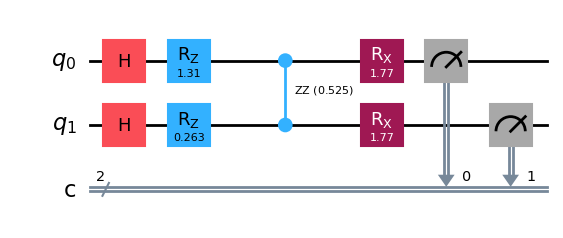

In [8]:
# Build the optimized p=1 circuit and display it.

optimized_qc = create_qaoa_circuit(
    gamma=best_gamma,
    beta=best_beta,
    p=1,
    measure=True
)

optimized_qc.draw("mpl")


## 4. Ideal Qiskit Aer measurement

We now run the actual circuit with finite shots.

The important quantity for the noise-scaling experiment is:

\[
P_\mathrm{opt} =

rac{	ext{counts of the classical-optimal bitstring}}
{	ext{total shots}}.
\]

Because Qiskit displays classical measurement strings in `q1 q0` order, the classical optimum `(x0,x1)=(0,0)` is the measured bitstring `"00"`.


In [9]:
SHOTS = 4096
OPTIMAL_BITSTRING = "00"

ideal_simulator = AerSimulator()

ideal_result = ideal_simulator.run(
    optimized_qc,
    shots=SHOTS
).result()

ideal_counts = ideal_result.get_counts()

ideal_optimal_probability = (
    ideal_counts.get(OPTIMAL_BITSTRING, 0) / SHOTS
)

print("Ideal Aer counts:")
print(ideal_counts)
print()
print(f"P(optimal = {OPTIMAL_BITSTRING}) = {ideal_optimal_probability:.4f}")


Ideal Aer counts:
{'11': 95, '01': 279, '00': 2178, '10': 1544}

P(optimal = 00) = 0.5317


## 5. Qiskit Aer depolarizing-noise model

We use an explicit depolarizing noise model.

- Single-qubit gates receive a 1-qubit depolarizing error.
- The two-qubit `RZZ` gate receives a 2-qubit depolarizing error.

This is a **representative noise model**, not a calibration model for a particular IBM device. Therefore, this notebook does not claim to simulate IBM Brisbane, Sherbrooke, or any other specific hardware.


In [10]:
def create_noise_model(noise_strength):
    if not 0 <= noise_strength <= 1:
        raise ValueError("noise_strength must be between 0 and 1")

    noise_model = NoiseModel()

    one_qubit_error = depolarizing_error(noise_strength, 1)
    two_qubit_error = depolarizing_error(noise_strength, 2)

    noise_model.add_all_qubit_quantum_error(
        one_qubit_error,
        ["h", "rz", "rx"]
    )

    noise_model.add_all_qubit_quantum_error(
        two_qubit_error,
        ["rzz"]
    )

    return noise_model


# Test that the noise model can be constructed.
test_noise_model = create_noise_model(0.01)
print("Noise model created successfully.")


Noise model created successfully.


In [11]:
def run_noisy_qaoa(gamma, beta, p, noise_strength, shots=4096):
    circuit = create_qaoa_circuit(
        gamma=gamma,
        beta=beta,
        p=p,
        measure=True
    )

    noise_model = create_noise_model(noise_strength)
    simulator = AerSimulator(noise_model=noise_model)

    result = simulator.run(
        circuit,
        shots=shots
    ).result()

    return result.get_counts()


# Quick test at 1% depolarizing noise.
test_counts = run_noisy_qaoa(
    best_gamma,
    best_beta,
    p=1,
    noise_strength=0.01,
    shots=SHOTS
)

print(test_counts)


{'11': 110, '01': 315, '00': 2101, '10': 1570}


## 6. Measured noise-scaling experiment

We now sweep the physical depolarizing-noise strength.

Unlike the old notebook's exponential formulas, the values below are obtained from **actual Qiskit Aer shot measurements**.


In [12]:
noise_levels = [
    0.000,
    0.001,
    0.005,
    0.010,
    0.020,
    0.050
]

noise_results = []

for noise_strength in noise_levels:
    counts = run_noisy_qaoa(
        gamma=best_gamma,
        beta=best_beta,
        p=1,
        noise_strength=noise_strength,
        shots=SHOTS
    )

    optimal_probability = (
        counts.get(OPTIMAL_BITSTRING, 0) / SHOTS
    )

    noise_results.append({
        "noise_strength": noise_strength,
        "optimal_probability": optimal_probability
    })

    print(
        f"Noise = {noise_strength:.3f} | "
        f"P(optimal) = {optimal_probability:.4f}"
    )

noise_df = pd.DataFrame(noise_results)
noise_df


Noise = 0.000 | P(optimal) = 0.5303
Noise = 0.001 | P(optimal) = 0.5354
Noise = 0.005 | P(optimal) = 0.5427
Noise = 0.010 | P(optimal) = 0.5312
Noise = 0.020 | P(optimal) = 0.5066
Noise = 0.050 | P(optimal) = 0.4744


,noise_strength,optimal_probability
0,0.000,0.530273
1,0.001,0.535400
2,0.005,0.542725
3,0.010,0.531250
4,0.020,0.506592
5,0.050,0.474365


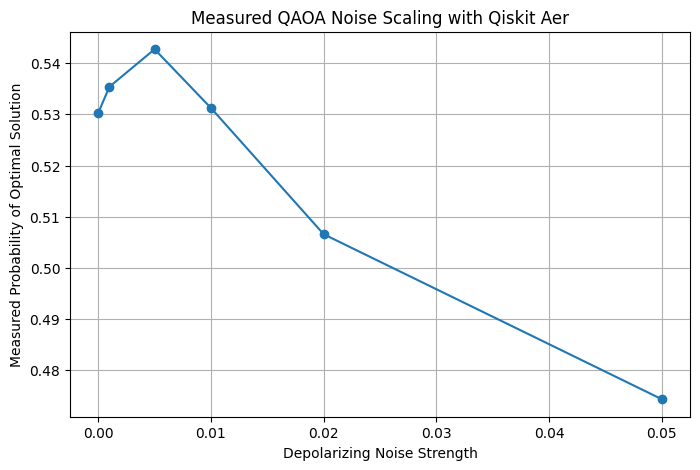

In [13]:
# Plot measured noise scaling.

plt.figure(figsize=(8, 5))

plt.plot(
    noise_df["noise_strength"],
    noise_df["optimal_probability"],
    marker="o"
)

plt.xlabel("Depolarizing Noise Strength")
plt.ylabel("Measured Probability of Optimal Solution")
plt.title("Measured QAOA Noise Scaling with Qiskit Aer")
plt.grid(True)
plt.show()


## 7. Quantitative noise impact

We report the change between the zero-noise Aer result and the largest noise level tested.


In [14]:
zero_noise_probability = noise_df.iloc[0]["optimal_probability"]
highest_noise_probability = noise_df.iloc[-1]["optimal_probability"]

absolute_drop = zero_noise_probability - highest_noise_probability

if zero_noise_probability > 0:
    percentage_drop = 100 * absolute_drop / zero_noise_probability
else:
    percentage_drop = np.nan

print(f"Zero-noise optimal probability: {zero_noise_probability:.4f}")
print(f"Highest-noise optimal probability: {highest_noise_probability:.4f}")
print(f"Absolute drop: {absolute_drop:.4f}")
print(f"Relative drop: {percentage_drop:.2f}%")


Zero-noise optimal probability: 0.5303
Highest-noise optimal probability: 0.4744
Absolute drop: 0.0559
Relative drop: 10.54%


## 8. QAOA depth versus measured noise

Increasing QAOA depth can improve the ideal optimization landscape, but it also creates a deeper circuit.

For each depth below, we optimize the QAOA parameters in an ideal statevector simulation and then measure the resulting circuit in Aer under the same representative noise model.


In [15]:
def optimize_qaoa_parameters(p):
    # Several starting points make the small optimization more robust.
    starts = [
        [0.2, 0.2],
        [0.5, 0.3],
        [1.0, 0.5],
        [1.5, 0.8]
    ]

    best_result = None

    for start in starts:
        result = minimize(
            qaoa_expectation,
            np.array(start, dtype=float),
            args=(p,),
            method="COBYLA",
            options={"maxiter": 150}
        )

        if best_result is None or result.fun < best_result.fun:
            best_result = result

    return (
        float(best_result.x[0]),
        float(best_result.x[1]),
        float(best_result.fun)
    )


depths = [1, 2, 3]

depth_results = []

for p in depths:
    gamma_p, beta_p, expectation_p = optimize_qaoa_parameters(p)

    counts = run_noisy_qaoa(
        gamma=gamma_p,
        beta=beta_p,
        p=p,
        noise_strength=0.01,
        shots=SHOTS
    )

    optimal_probability = counts.get(OPTIMAL_BITSTRING, 0) / SHOTS

    circuit_without_measurement = create_qaoa_circuit(
        gamma_p,
        beta_p,
        p=p,
        measure=False
    )

    depth_results.append({
        "QAOA layers p": p,
        "gamma": gamma_p,
        "beta": beta_p,
        "ideal expected cost": expectation_p,
        "Aer circuit depth": circuit_without_measurement.depth(),
        "P(optimal) at 1% noise": optimal_probability
    })

depth_df = pd.DataFrame(depth_results)
depth_df


,QAOA layers p,gamma,beta,ideal expected cost,Aer circuit depth,P(optimal) at 1% noise
0,1,0.262617,0.887334,0.921880,4,0.531250
1,2,0.171438,0.528752,0.549645,7,0.636719
2,3,0.123143,0.373993,0.487613,10,0.653076


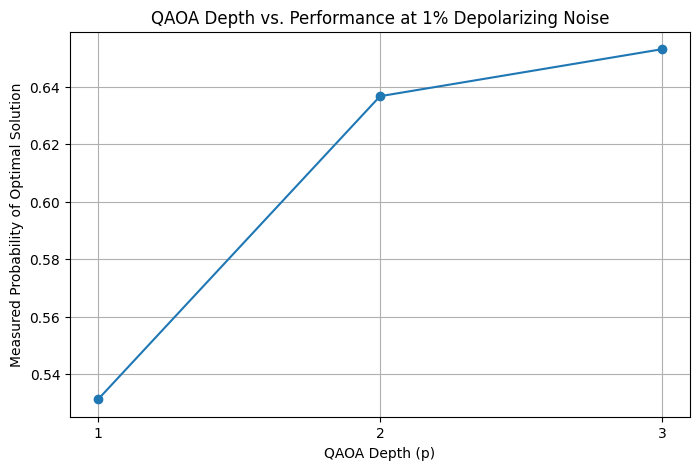

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_df["QAOA layers p"],
    depth_df["P(optimal) at 1% noise"],
    marker="o"
)

plt.xlabel("QAOA Depth (p)")
plt.ylabel("Measured Probability of Optimal Solution")
plt.title("QAOA Depth vs. Performance at 1% Depolarizing Noise")
plt.xticks(depths)
plt.grid(True)
plt.show()


## 9. Measured Zero-Noise Extrapolation (ZNE)

ZNE estimates the zero-noise value by executing the circuit at several increased noise strengths and fitting a polynomial.

Here we use noise scaling factors

\[
\lambda = 1,\;1.5,\;2,\;3
\]

and extrapolate the measured probability toward \(\lambda=0\).

This is a **software error-mitigation experiment on Aer**. It is not a claim of error mitigation on physical quantum hardware.


In [17]:
base_noise = 0.01
zne_factors = np.array([1.0, 1.5, 2.0, 3.0])

zne_probabilities = []

for factor in zne_factors:
    scaled_noise = base_noise * factor

    counts = run_noisy_qaoa(
        gamma=best_gamma,
        beta=best_beta,
        p=1,
        noise_strength=scaled_noise,
        shots=SHOTS
    )

    probability = counts.get(OPTIMAL_BITSTRING, 0) / SHOTS
    zne_probabilities.append(probability)

    print(
        f"Scale factor = {factor:.1f}, "
        f"noise = {scaled_noise:.3f}, "
        f"P(optimal) = {probability:.4f}"
    )

zne_probabilities = np.array(zne_probabilities)

# Quadratic extrapolation to zero noise.
zne_coefficients = np.polyfit(
    zne_factors,
    zne_probabilities,
    2
)

zne_mitigated_probability = float(
    np.polyval(zne_coefficients, 0.0)
)

# Keep the reported value in the physical probability range.
zne_mitigated_probability = np.clip(
    zne_mitigated_probability,
    0.0,
    1.0
)

print()
print(f"ZNE extrapolated P(optimal) at zero noise: {zne_mitigated_probability:.4f}")


Scale factor = 1.0, noise = 0.010, P(optimal) = 0.5417
Scale factor = 1.5, noise = 0.015, P(optimal) = 0.5129
Scale factor = 2.0, noise = 0.020, P(optimal) = 0.5195
Scale factor = 3.0, noise = 0.030, P(optimal) = 0.5242

ZNE extrapolated P(optimal) at zero noise: 0.6013


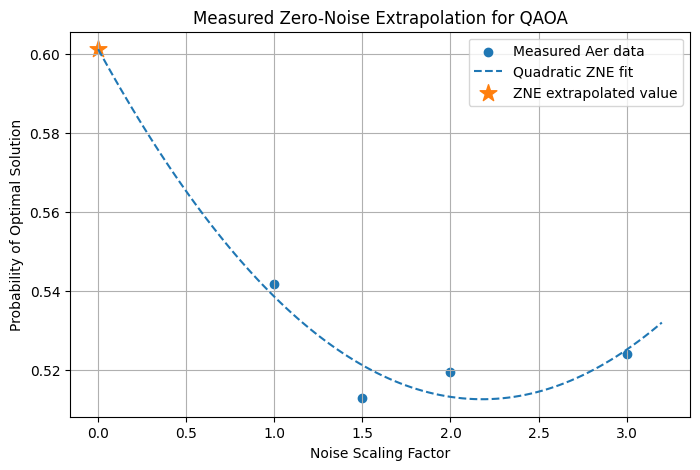

In [18]:
# ZNE visualization

fit_x = np.linspace(0, 3.2, 100)
fit_y = np.polyval(zne_coefficients, fit_x)

plt.figure(figsize=(8, 5))

plt.scatter(
    zne_factors,
    zne_probabilities,
    label="Measured Aer data"
)

plt.plot(
    fit_x,
    fit_y,
    linestyle="--",
    label="Quadratic ZNE fit"
)

plt.scatter(
    [0],
    [zne_mitigated_probability],
    marker="*",
    s=160,
    label="ZNE extrapolated value"
)

plt.xlabel("Noise Scaling Factor")
plt.ylabel("Probability of Optimal Solution")
plt.title("Measured Zero-Noise Extrapolation for QAOA")
plt.grid(True)
plt.legend()
plt.show()


## 10. Final quantitative summary

The final table combines the classical optimum, ideal Aer measurement, the noisy measurement, and the ZNE estimate.


In [19]:
summary_df = pd.DataFrame({
    "Metric": [
        "Classical optimal objective",
        "Classical optimal bitstring",
        "Ideal Aer P(optimal)",
        "Aer P(optimal) at 1% noise",
        "ZNE extrapolated P(optimal)"
    ],
    "Value": [
        optimal_cost,
        str(optimal_bits),
        float(noise_df.loc[noise_df["noise_strength"] == 0.0, "optimal_probability"].iloc[0]),
        float(noise_df.loc[noise_df["noise_strength"] == 0.01, "optimal_probability"].iloc[0]),
        zne_mitigated_probability
    ]
})

summary_df


,Metric,Value
0,Classical optimal objective,0
1,Classical optimal bitstring,"(0, 0)"
2,Ideal Aer P(optimal),0.530273
3,Aer P(optimal) at 1% noise,0.53125
4,ZNE extrapolated P(optimal),0.601252


## 11. Conclusion

### What has been demonstrated

- A classical EV/V2G scheduling objective was written as a QUBO.
- The same objective was solved exactly with a classical brute-force baseline.
- A genuine QAOA circuit was constructed using Qiskit.
- The circuit is displayed graphically using Qiskit's Matplotlib drawer.
- QAOA parameters were optimized using an ideal statevector simulation.
- The optimized circuit was executed with finite-shot Qiskit Aer simulation.
- A depolarizing noise model was applied and the optimal-solution probability was measured at multiple noise strengths.
- QAOA depth was tested under noise.
- ZNE was demonstrated using measured Aer data.

### Limitation

This is a small 2-variable demonstration QUBO. The measured noise results characterize the chosen Aer depolarizing model, not a real quantum processor. Therefore, the results should be described as **Qiskit Aer noisy-simulation results** in the hackathon presentation.

For a larger EV/V2G fleet model, the same QUBO-to-QAOA workflow can be extended to more binary scheduling variables, followed by a direct comparison against the project's classical optimizer.


In [20]:
# Optional: save the main measured results as CSV files.

noise_df.to_csv("measured_noise_scaling.csv", index=False)
depth_df.to_csv("measured_depth_scaling.csv", index=False)
summary_df.to_csv("quantum_experiment_summary.csv", index=False)

print("Saved:")
print(" - measured_noise_scaling.csv")
print(" - measured_depth_scaling.csv")
print(" - quantum_experiment_summary.csv")


Saved:
 - measured_noise_scaling.csv
 - measured_depth_scaling.csv
 - quantum_experiment_summary.csv
